# Ordinal Data
Feature reduction, redundancy and feature engineering

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = pd.read_csv("Data/ordinal_train_cleaned.csv")
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X

,OverallQual,OverallQual.1,OverallCond,MSSubClass,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,LotShape,LandSlope,LandContour,SaleCondition
0,7,7,5,60,4,3,4,3,1,6,...,5,4,4,2,3,3,3,2,3,4
1,6,6,8,20,3,3,4,3,4,5,...,5,3,3,2,3,3,3,2,3,4
2,7,7,5,60,4,3,4,3,2,6,...,5,4,3,2,3,3,2,2,3,4
3,7,7,5,70,3,3,3,4,1,5,...,4,4,4,1,3,3,2,2,3,0
4,8,8,5,60,4,3,4,3,3,6,...,5,4,3,2,3,3,2,2,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,5,60,3,3,4,3,1,1,...,5,3,3,2,3,3,3,2,3,4
1408,6,6,6,20,3,3,4,3,1,5,...,3,3,3,1,3,3,3,2,3,4
1409,7,7,9,70,5,4,3,4,1,6,...,5,4,4,2,3,3,3,2,3,4
1410,5,5,6,20,3,3,3,3,2,6,...,4,4,4,1,3,3,3,2,3,4


# Mutual Information Score
as first feature reduction criterion

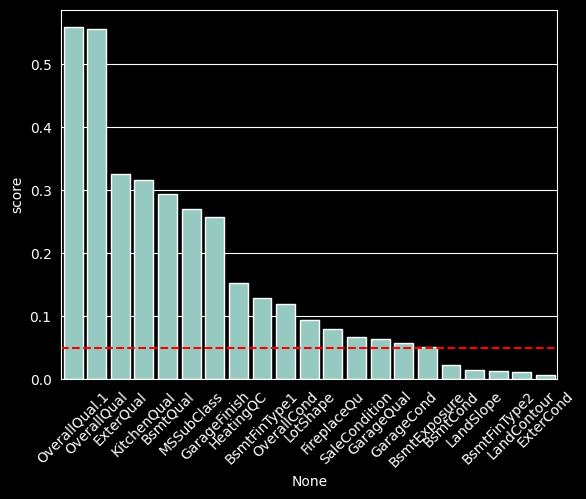

In [45]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

And We take those having MI score grater than 0.05

In [46]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]
removed_x = X[mi_series[mi_series.values < 0.05].keys()]

selected_X

,OverallQual.1,OverallQual,ExterQual,KitchenQual,BsmtQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,LotShape,FireplaceQu,SaleCondition,GarageQual,GarageCond,BsmtExposure
0,7,7,4,4,4,60,2,5,6,5,3,4,4,3,3,1
1,6,6,3,3,4,20,2,5,5,8,3,3,4,3,3,4
2,7,7,4,4,4,60,2,5,6,5,2,3,4,3,3,2
3,7,7,3,4,3,70,1,4,5,5,2,4,0,3,3,1
4,8,8,4,4,4,60,2,5,6,5,2,3,4,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,3,3,4,60,2,5,1,5,3,3,4,3,3,1
1408,6,6,3,3,4,20,1,3,5,6,3,3,4,3,3,1
1409,7,7,5,4,3,70,2,5,6,9,3,4,4,3,3,1
1410,5,5,3,4,3,20,1,4,6,6,3,4,4,3,3,2


# Vizualizations
with target

## Selected X
to check if categories are correlated with target

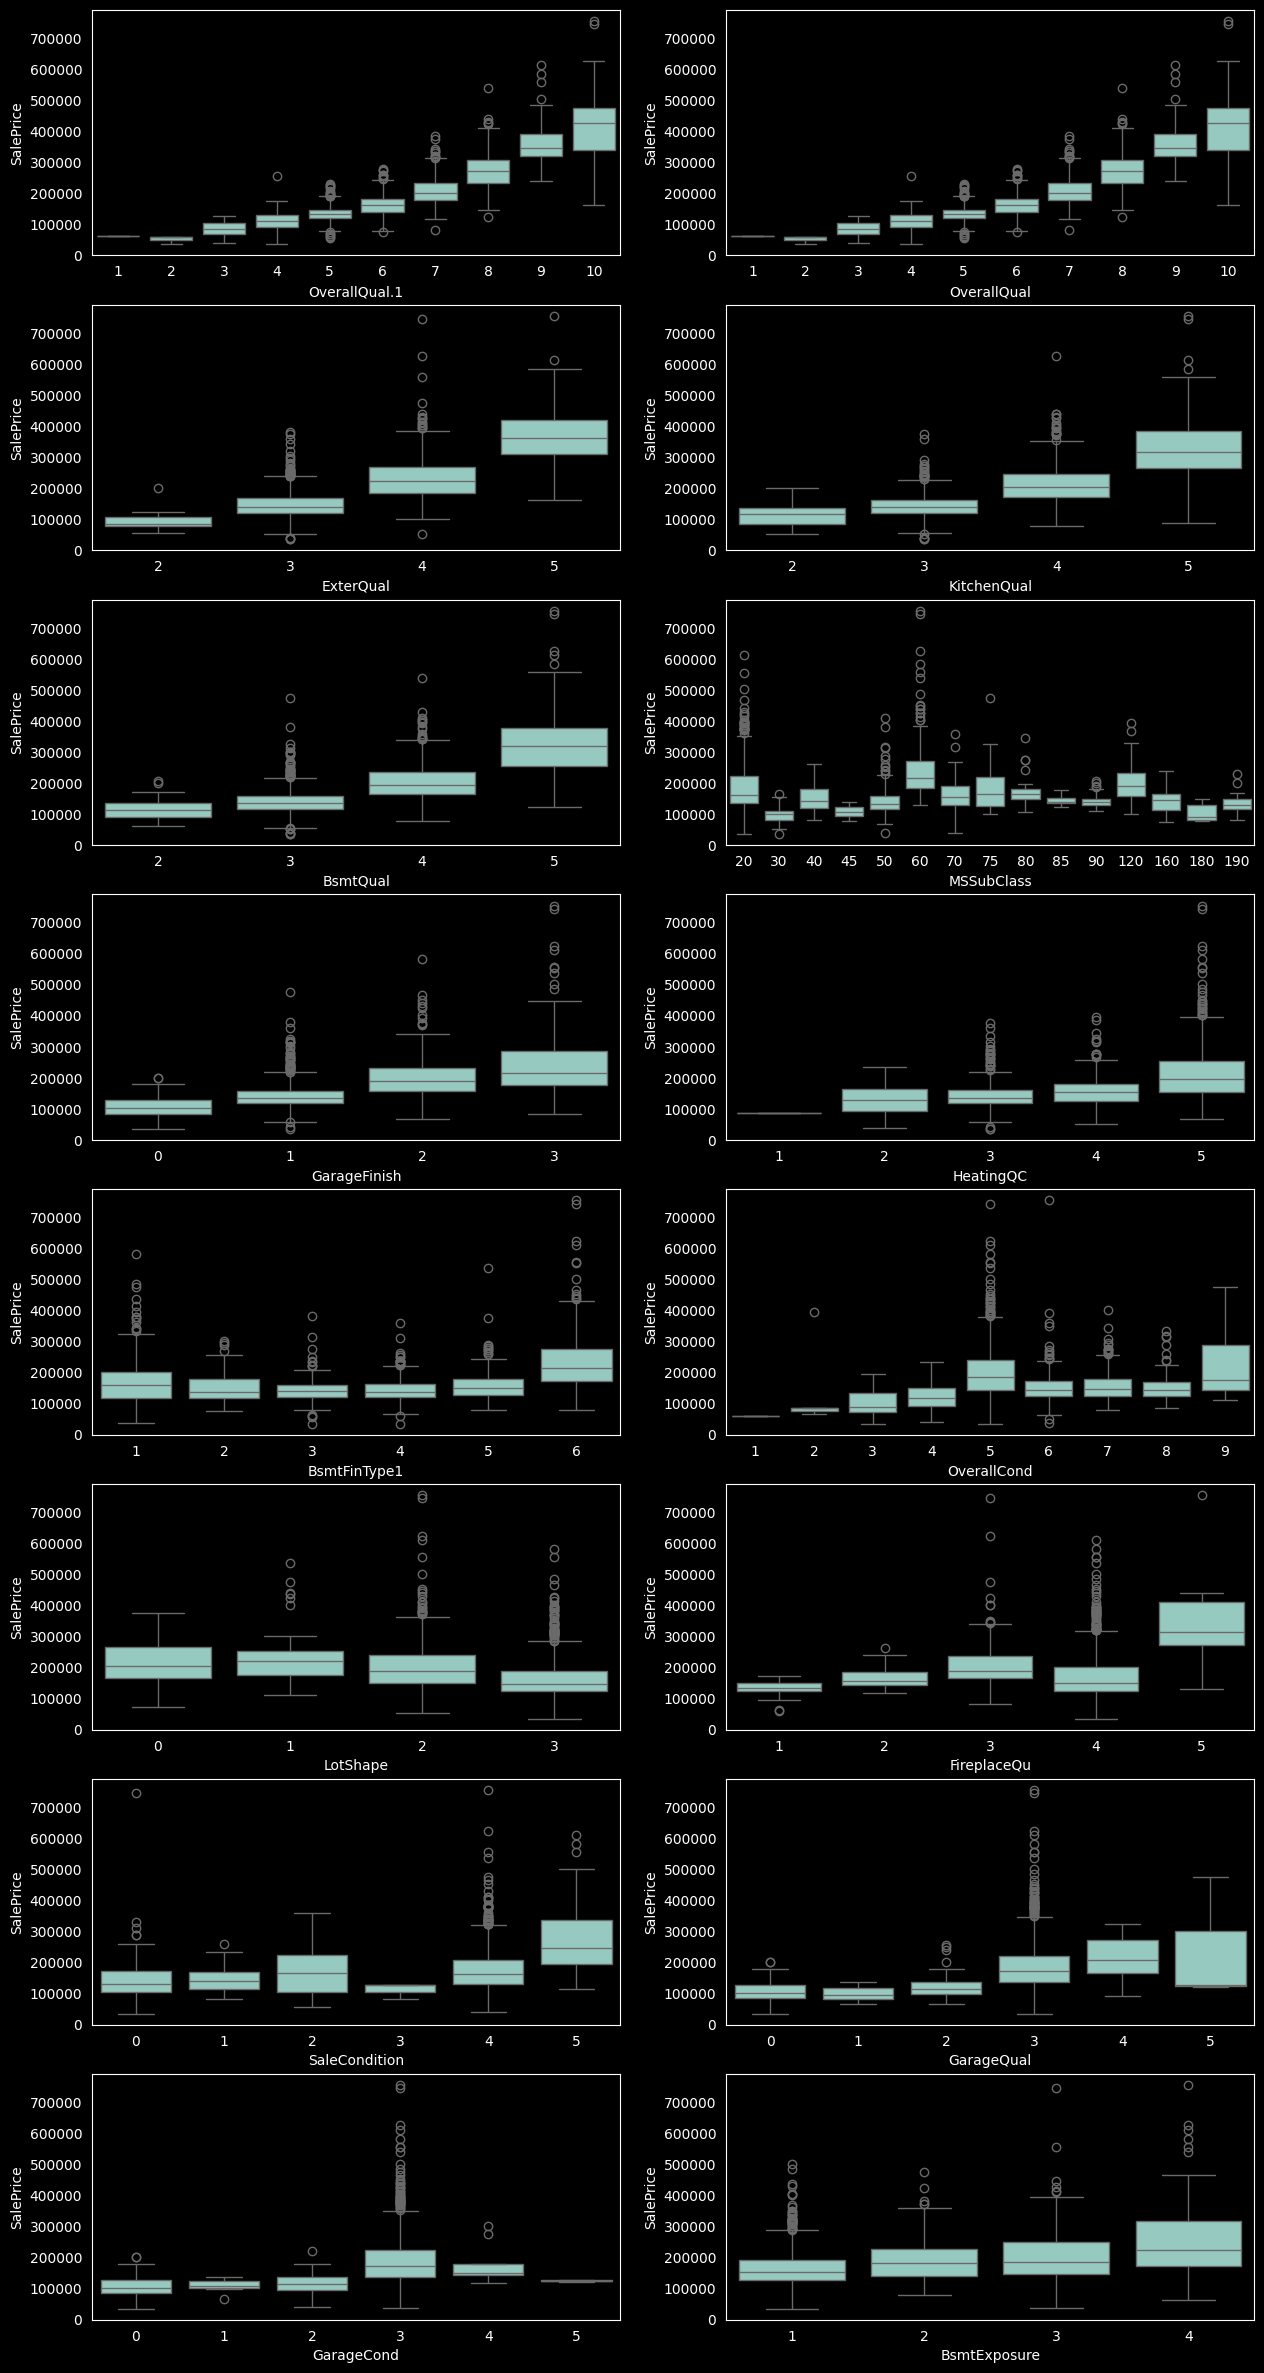

In [47]:
fig, ax = plt.subplots(8,2, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(selected_X.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Unselected X

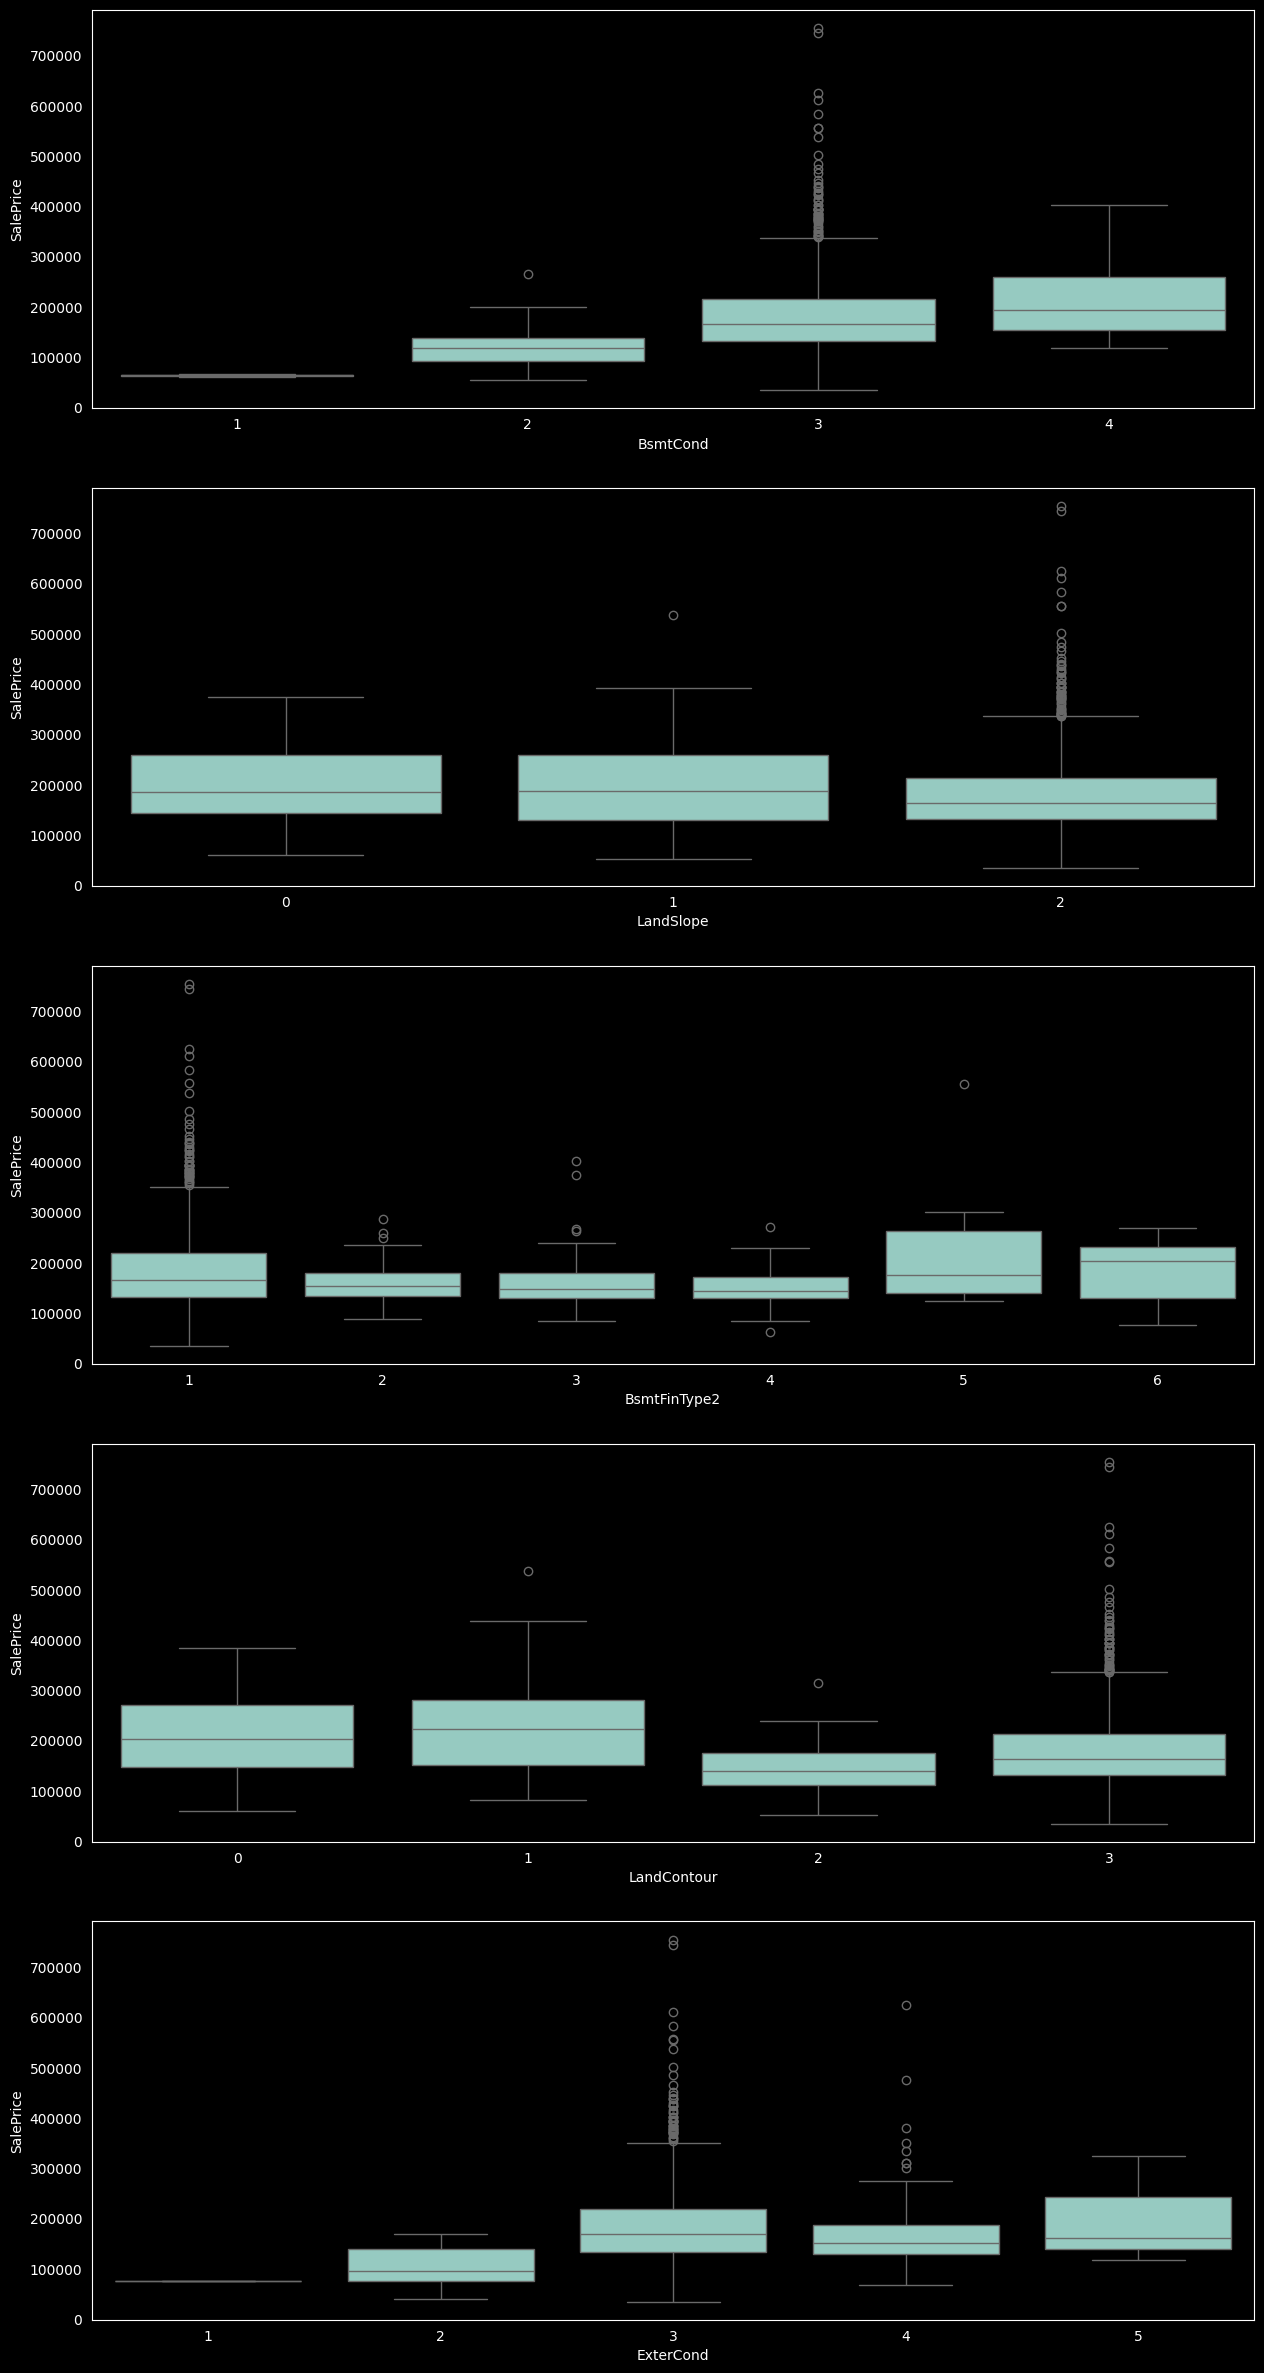

In [48]:
fig, ax = plt.subplots(5,1, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(removed_x.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Additional reduction
Basing on plots and analyzing correlation with target `BsmtQual` is removed. Rest stays the same.


In [49]:
new_X = selected_X.drop('BsmtQual', axis=1)

##  Correlation

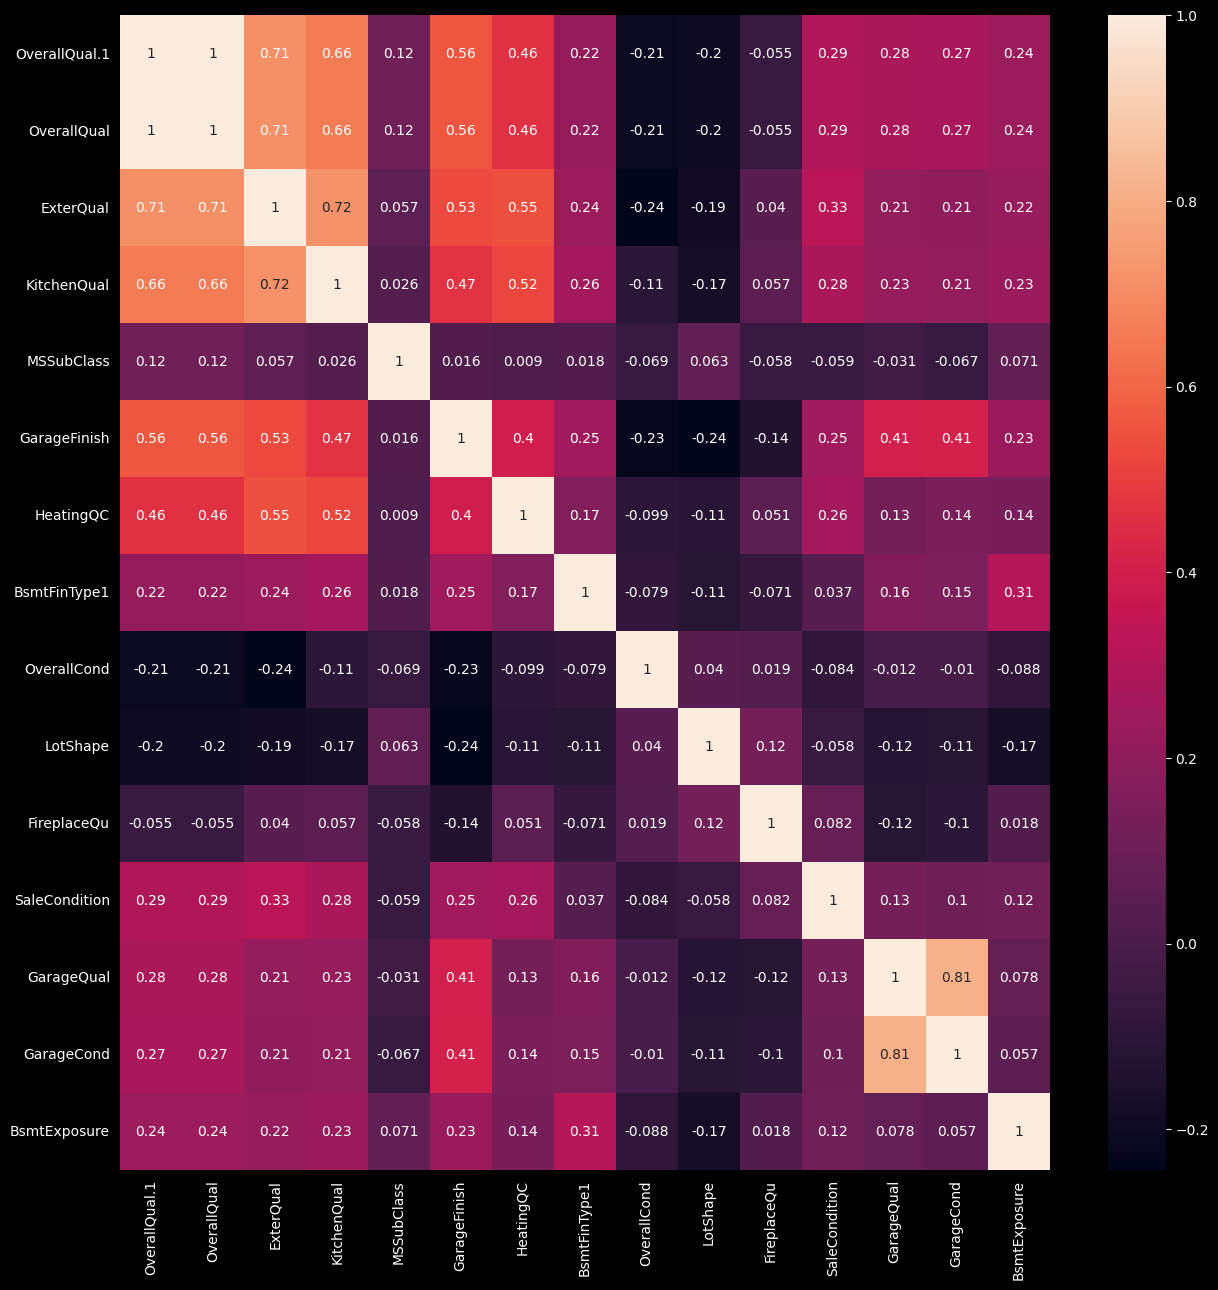

In [57]:
corr_mtx = new_X.corr(method='spearman')

plt.figure(figsize=(15,15))
sns.heatmap(corr_mtx, annot=True)
plt.show()

### Removing highly corralated features

In [55]:
uncor_x = new_X.drop(['OverallQual','GarageCond' ], axis=1)

uncor_x

,OverallQual.1,ExterQual,KitchenQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,LotShape,FireplaceQu,SaleCondition,GarageQual,BsmtExposure
0,7,4,4,60,2,5,6,5,3,4,4,3,1
1,6,3,3,20,2,5,5,8,3,3,4,3,4
2,7,4,4,60,2,5,6,5,2,3,4,3,2
3,7,3,4,70,1,4,5,5,2,4,0,3,1
4,8,4,4,60,2,5,6,5,2,3,4,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,3,3,60,2,5,1,5,3,3,4,3,1
1408,6,3,3,20,1,3,5,6,3,3,4,3,1
1409,7,5,4,70,2,5,6,9,3,4,4,3,1
1410,5,3,4,20,1,4,6,6,3,4,4,3,2


# PCA Analysis

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

pca.fit(uncor_x)


df_components = pd.DataFrame()

df_PCA = pd.DataFrame(pca.components_.T, index=uncor_x.columns)
df_PCA

,0,1,2,3
OverallQual.1,0.001252,0.322440,0.625272,-0.064188
ExterQual,0.000323,0.127887,0.221681,-0.019151
KitchenQual,-0.000111,0.148463,0.228841,0.006411
MSSubClass,0.999993,-0.001896,0.000240,0.001776
GarageFinish,-0.000522,0.196517,0.289148,-0.084713
HeatingQC,-0.000130,0.152498,0.298964,0.069174
BsmtFinType1,0.001652,0.853577,-0.495398,0.035766
OverallCond,-0.001661,-0.057141,-0.112940,0.728409
LotShape,0.001572,-0.052992,-0.060618,0.027437
FireplaceQu,-0.000145,-0.013147,0.028471,0.013874
